In [ ]:
#Import the libaraies
import pandas as pd
import numpy as np

print(" Libraries loaded successfully!")

 Libraries loaded successfully!


In [ ]:
# Load the training data
train_df = pd.read_csv('train.csv')

# Load the test data
test_df = pd.read_csv('test.csv')

print(" Data loaded successfully!")
print(f"Training data: {train_df.shape[0]} rows and {train_df.shape[1]} columns")
print(f"Test data: {test_df.shape[0]} rows and {test_df.shape[1]} columns")

 Data loaded successfully!
Training data: 891 rows and 12 columns
Test data: 418 rows and 11 columns


In [ ]:
# Show the first 5 rows of training data
print(train_df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [ ]:
# Get information about the data
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [ ]:
# Count missing values in each column
print(train_df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
# Get statistical summary of the data
print("Statistical Summary:")
print(train_df.describe())

Statistical Summary:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
print(" Visualization libraries loaded!")

 Visualization libraries loaded!


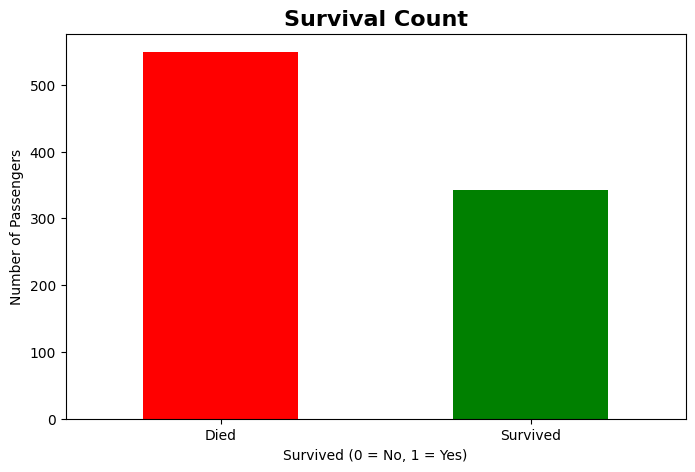

Died: 549 passengers
Survived: 342 passengers


In [ ]:
# Create a bar chart showing survival counts
plt.figure(figsize=(8, 5))
train_df['Survived'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Survival Count', fontsize=16, fontweight='bold')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.xticks([0, 1], ['Died', 'Survived'], rotation=0)
plt.show()

print(f"Died: {train_df['Survived'].value_counts()[0]} passengers")
print(f"Survived: {train_df['Survived'].value_counts()[1]} passengers")

In [ ]:
# Compare survival by gender
survival_by_gender = pd.crosstab(train_df['Sex'], train_df['Survived'])
print("Survival by Gender:")
print(survival_by_gender)

# Calculate survival rate by gender
print("\nSurvival Rate:")
print(train_df.groupby('Sex')['Survived'].mean())

Survival by Gender:
Survived    0    1
Sex               
female     81  233
male      468  109

Survival Rate:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


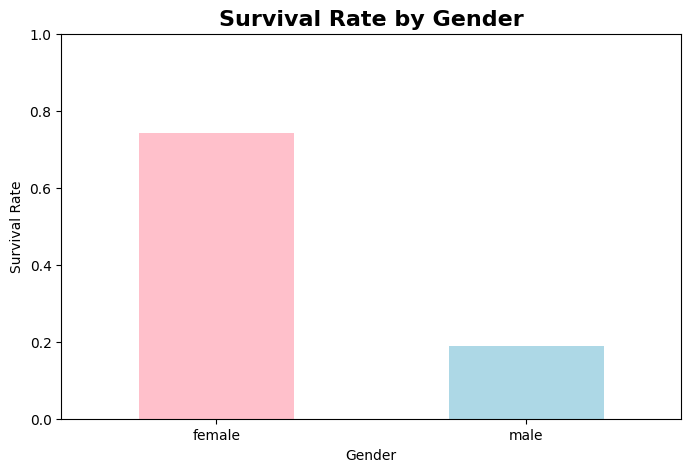

In [ ]:
# Create a chart showing survival by gender
survival_rate_by_gender = train_df.groupby('Sex')['Survived'].mean()

plt.figure(figsize=(8, 5))
survival_rate_by_gender.plot(kind='bar', color=['pink', 'lightblue'])
plt.title('Survival Rate by Gender', fontsize=16, fontweight='bold')
plt.ylabel('Survival Rate')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.ylim(0, 1)



plt.show()

In [ ]:
# Check survival by passenger class
survival_by_class = pd.crosstab(train_df['Pclass'], train_df['Survived'])
print("Survival by Passenger Class:")
print(survival_by_class)

# Calculate survival rate
print("\nSurvival Rate by Class:")
print(train_df.groupby('Pclass')['Survived'].mean())

Survival by Passenger Class:
Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119

Survival Rate by Class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


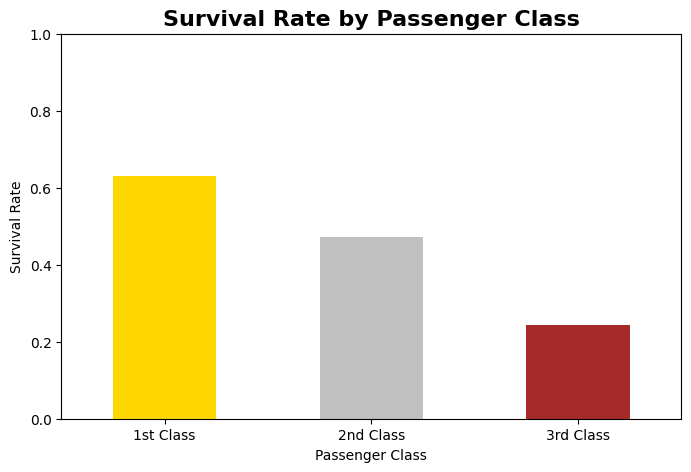

In [ ]:
# Visualize survival rate by class
survival_rate_by_class = train_df.groupby('Pclass')['Survived'].mean()

plt.figure(figsize=(8, 5))
survival_rate_by_class.plot(kind='bar', color=['gold', 'silver', 'brown'])
plt.title('Survival Rate by Passenger Class', fontsize=16, fontweight='bold')
plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class')
plt.xticks([0, 1, 2], ['1st Class', '2nd Class', '3rd Class'], rotation=0)
plt.ylim(0, 1)


plt.show()



In [ ]:
# Check missing values again
print(train_df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
# Check missing values in test data
print(test_df.isnull().sum())

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [ ]:
# 1. Fill missing AGE with the median age
median_age = train_df['Age'].median()
train_df['Age'] = train_df['Age'].fillna(median_age)
test_df['Age'] = test_df['Age'].fillna(median_age)

print(f"Filled missing Age with median: {median_age}")

Filled missing Age with median: 28.0


In [ ]:
# 2. Fill missing EMBARKED with the most common port
most_common_port = train_df['Embarked'].mode()[0]
train_df['Embarked'] = train_df['Embarked'].fillna(most_common_port)
test_df['Embarked'] = test_df['Embarked'].fillna(most_common_port)

print(f" Filled missing Embarked with: {most_common_port}")

 Filled missing Embarked with: S


In [ ]:
# 3. Fill missing FARE in test data (some test rows have missing fare)
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())

print("Filled missing Fare in test data")

Filled missing Fare in test data


In [ ]:
# TRAIN data - Missing values after cleaning:
print(train_df.isnull().sum())

print("\n" + "="*50)

# TEST data - Missing values after cleaning:
print(test_df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64


In [ ]:
# Create new features for both train and test data

# 1. family size = SibSp + Parch + 1 (the person themselves)
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1

print("Created FamilySize feature")

# 2. Is alone = 1 if traveling alone, 0 if with family
train_df['IsAlone'] = (train_df['FamilySize'] == 1).astype(int)
test_df['IsAlone'] = (test_df['FamilySize'] == 1).astype(int)

print(" Created IsAlone feature")

# Check the new features
print("\n" + "="*50)
print("New features created! Here are some examples:")
print(train_df[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head(10))

Created FamilySize feature
 Created IsAlone feature

New features created! Here are some examples:
   SibSp  Parch  FamilySize  IsAlone
0      1      0           2        0
1      1      0           2        0
2      0      0           1        1
3      1      0           2        0
4      0      0           1        1
5      0      0           1        1
6      0      0           1        1
7      3      1           5        0
8      0      2           3        0
9      1      0           2        0


In [ ]:
# Convert sex: male=0, female=1
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})

print(" Converted Sex to numbers (male=0, female=1)")

# Convert embarked: S=0, C=1, Q=2
train_df['Embarked'] = train_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
test_df['Embarked'] = test_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print(" Converted Embarked to numbers (S=0, C=1, Q=2)")

print("\n" + "="*50)
print("Sample of converted data:")
print(train_df.head(10))

 Converted Sex to numbers (male=0, female=1)
 Converted Embarked to numbers (S=0, C=1, Q=2)

Sample of converted data:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    0  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0   
2                             Heikkinen, Miss. Laina    1  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1      0   
4                           Allen, Mr. William Henry    0  35.0      0      0  

In [ ]:
# Columns we want to drop (not useful)
drop_columns = ['PassengerId', 'Name', 'Ticket', 'Cabin']

# Create feature set (X) and target (y)
X = train_df.drop(columns=drop_columns + ['Survived'])
y = train_df['Survived']

# Do the same for test data (but no 'Survived' column in test)
X_test = test_df.drop(columns=drop_columns)

print(" Features selected!")
print(f"\nFeatures we're using: {list(X.columns)}")
print(f"Number of features: {len(X.columns)}")
print(f"\nTraining data shape: {X.shape}")
print(f"Test data shape: {X_test.shape}")

 Features selected!

Features we're using: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']
Number of features: 9

Training data shape: (891, 9)
Test data shape: (418, 9)


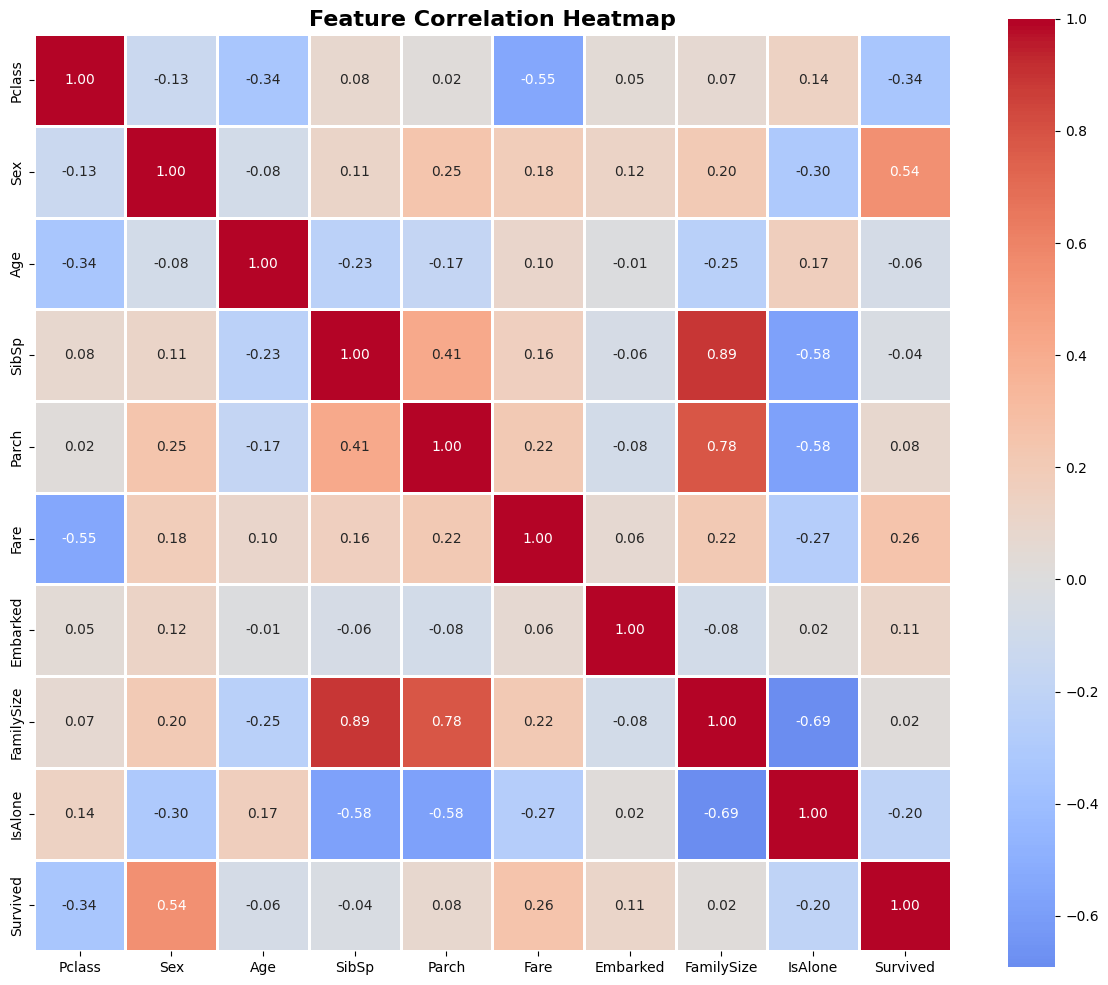


CORRELATION WITH SURVIVAL (sorted by strength):
Survived      1.000000
Sex           0.543351
Fare          0.257307
Embarked      0.106811
Parch         0.081629
FamilySize    0.016639
SibSp        -0.035322
Age          -0.064910
IsAlone      -0.203367
Pclass       -0.338481
Name: Survived, dtype: float64

 Interpretation:
  • Positive correlation = higher value → more likely to survive
  • Negative correlation = higher value → less likely to survive
  • Values closer to -1 or +1 = stronger relationship


In [ ]:
# Import visualization library
import seaborn as sns
import matplotlib.pyplot as plt

# Create correlation matrix
# We need to add 'Survived' back to see correlations with our target
correlation_data = X.copy()
correlation_data['Survived'] = y

# Calculate correlations
correlation_matrix = correlation_data.corr()

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=1)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Show correlations with Survived specifically
print("\n" + "="*60)
print("CORRELATION WITH SURVIVAL (sorted by strength):")
print("="*60)
survival_corr = correlation_matrix['Survived'].sort_values(ascending=False)
print(survival_corr)

print("\n Interpretation:")
print("  • Positive correlation = higher value → more likely to survive")
print("  • Negative correlation = higher value → less likely to survive")
print("  • Values closer to -1 or +1 = stronger relationship")

Fare statistics:
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

Age statistics:
count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64


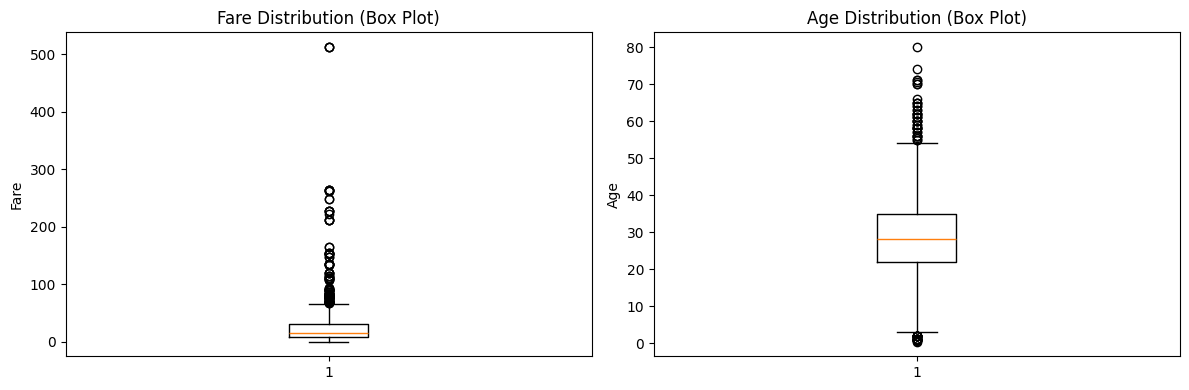


 In the box plots, dots above/below the boxes are outliers


In [ ]:
# Check for outliers in Fare column
print("Fare statistics:")
print(train_df['Fare'].describe())

print("\n" + "="*50)
print("Age statistics:")
print(train_df['Age'].describe())

# Visualize outliers
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Fare boxplot
axes[0].boxplot(train_df['Fare'].dropna())
axes[0].set_title('Fare Distribution (Box Plot)')
axes[0].set_ylabel('Fare')

# Age boxplot
axes[1].boxplot(train_df['Age'].dropna())
axes[1].set_title('Age Distribution (Box Plot)')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

print("\n In the box plots, dots above/below the boxes are outliers")

In [ ]:
# Import scaling library
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit and transform training data
X_scaled = scaler.fit_transform(X)

# Transform test data (use same scaler!)
X_test_scaled = scaler.transform(X_test)

print("Data scaled!")
print(f"Original X shape: {X.shape}")
print(f"Scaled X shape: {X_scaled.shape}")

# Show BEFORE scaling (first 5 rows)
print("\n" + "="*60)
print("BEFORE SCALING - First 5 passengers:")
print("="*60)
print(X.head())

# Show AFTER scaling (first 5 rows)
# Convert scaled array back to DataFrame for better viewing
import pandas as pd
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\n" + "="*60)
print("AFTER SCALING - First 5 passengers:")
print("="*60)
print(X_scaled_df.head())



Data scaled!
Original X shape: (891, 9)
Scaled X shape: (891, 9)

BEFORE SCALING - First 5 passengers:
   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  FamilySize  IsAlone
0       3    0  22.0      1      0   7.2500         0           2        0
1       1    1  38.0      1      0  71.2833         1           2        0
2       3    1  26.0      0      0   7.9250         0           1        1
3       1    1  35.0      1      0  53.1000         0           2        0
4       3    0  35.0      0      0   8.0500         0           1        1

AFTER SCALING - First 5 passengers:
     Pclass       Sex       Age     SibSp     Parch      Fare  Embarked  \
0  0.827377 -0.737695 -0.565736  0.432793 -0.473674 -0.502445 -0.568837   
1 -1.566107  1.355574  0.663861  0.432793 -0.473674  0.786845  1.005181   
2  0.827377  1.355574 -0.258337 -0.474545 -0.473674 -0.488854 -0.568837   
3 -1.566107  1.355574  0.433312  0.432793 -0.473674  0.420730 -0.568837   
4  0.827377 -0.737695  0.433312 -0.

In [ ]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split the scaled data: 80% training, 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(" Data split complete!")
print(f"\nTotal training data: {len(X_scaled)} passengers")
print(f"Training set: {len(X_train)} passengers ({len(X_train)/len(X_scaled)*100:.1f}%)")
print(f"Validation set: {len(X_val)} passengers ({len(X_val)/len(X_scaled)*100:.1f}%)")

print(f"\nTraining set survival distribution:")
print(f"  Died: {(y_train == 0).sum()}")
print(f"  Survived: {(y_train == 1).sum()}")

print(f"\nValidation set survival distribution:")
print(f"  Died: {(y_val == 0).sum()}")
print(f"  Survived: {(y_val == 1).sum()}")

 Data split complete!

Total training data: 891 passengers
Training set: 712 passengers (79.9%)
Validation set: 179 passengers (20.1%)

Training set survival distribution:
  Died: 439
  Survived: 273

Validation set survival distribution:
  Died: 110
  Survived: 69


 Training Logistic Regression model...
Model trained successfully!

MODEL PERFORMANCE:
Validation Accuracy: 0.8045 (80.45%)

DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Died       0.82      0.88      0.85       110
    Survived       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


CONFUSION MATRIX:
[[97 13]
 [22 47]]

Interpretation:
  True Negatives (Correctly predicted Died): 97
  False Positives (Predicted Survived, but Actually Died): 13
  False Negatives (Predicted Died, but Actually Survived): 22
  True Positives (Correctly predicted Survived): 47

Out of 179 passengers, we predicted 144 correctly!


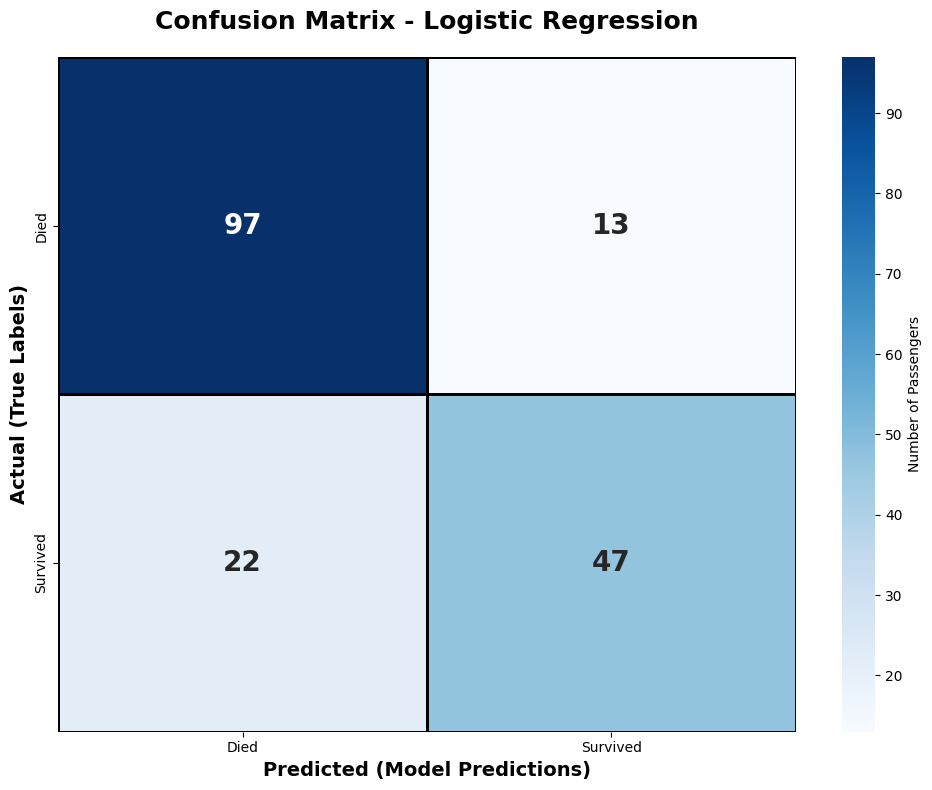


DETAILED BREAKDOWN:

 CORRECT PREDICTIONS: 144 out of 179 (80.4%)
   • True Negatives (Died → Died): 97
   • True Positives (Survived → Survived): 47

 INCORRECT PREDICTIONS: 35 out of 179 (19.6%)
   • False Positives (Died → Survived): 13 - Model too optimistic
   • False Negatives (Survived → Died): 22 - Model too pessimistic

 MODEL BEHAVIOR:
   • Total who actually died: 110
   • Total who actually survived: 69
   • Total predicted to die: 119
   • Total predicted to survive: 60


In [ ]:
# Import Logistic Regression and evaluation metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create the model
model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
print(" Training Logistic Regression model...")
model.fit(X_train, y_train)
print("Model trained successfully!")

# Make predictions on validation set
y_pred = model.predict(X_val)

# Calculate accuracy
accuracy = accuracy_score(y_val, y_pred)

print("\n" + "="*60)
print("MODEL PERFORMANCE:")
print("="*60)
print(f"Validation Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Detailed classification report
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT:")
print("="*60)
print(classification_report(y_val, y_pred, target_names=['Died', 'Survived']))

# Confusion Matrix
print("\n" + "="*60)
print("CONFUSION MATRIX:")
print("="*60)
cm = confusion_matrix(y_val, y_pred)
print(cm)
print("\nInterpretation:")
print(f"  True Negatives (Correctly predicted Died): {cm[0,0]}")
print(f"  False Positives (Predicted Survived, but Actually Died): {cm[0,1]}")
print(f"  False Negatives (Predicted Died, but Actually Survived): {cm[1,0]}")
print(f"  True Positives (Correctly predicted Survived): {cm[1,1]}")

print(f"\nOut of {len(y_val)} passengers, we predicted {int(accuracy*len(y_val))} correctly!")

# ============================================================
# VISUALIZE CONFUSION MATRIX
# ============================================================

# Create figure
plt.figure(figsize=(10, 8))

# Create heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'],
            cbar_kws={'label': 'Number of Passengers'},
            linewidths=2, linecolor='black',
            annot_kws={'size': 20, 'weight': 'bold'})

plt.title('Confusion Matrix - Logistic Regression', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Actual (True Labels)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted (Model Predictions)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# DETAILED BREAKDOWN
# ============================================================

print("\n" + "="*60)
print("DETAILED BREAKDOWN:")
print("="*60)

total = len(y_val)
tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

print(f"\n CORRECT PREDICTIONS: {tn + tp} out of {total} ({(tn+tp)/total*100:.1f}%)")
print(f"   • True Negatives (Died → Died): {tn}")
print(f"   • True Positives (Survived → Survived): {tp}")

print(f"\n INCORRECT PREDICTIONS: {fp + fn} out of {total} ({(fp+fn)/total*100:.1f}%)")
print(f"   • False Positives (Died → Survived): {fp} - Model too optimistic")
print(f"   • False Negatives (Survived → Died): {fn} - Model too pessimistic")

print(f"\n MODEL BEHAVIOR:")
print(f"   • Total who actually died: {cm[0,:].sum()}")
print(f"   • Total who actually survived: {cm[1,:].sum()}")
print(f"   • Total predicted to die: {cm[:,0].sum()}")
print(f"   • Total predicted to survive: {cm[:,1].sum()}")



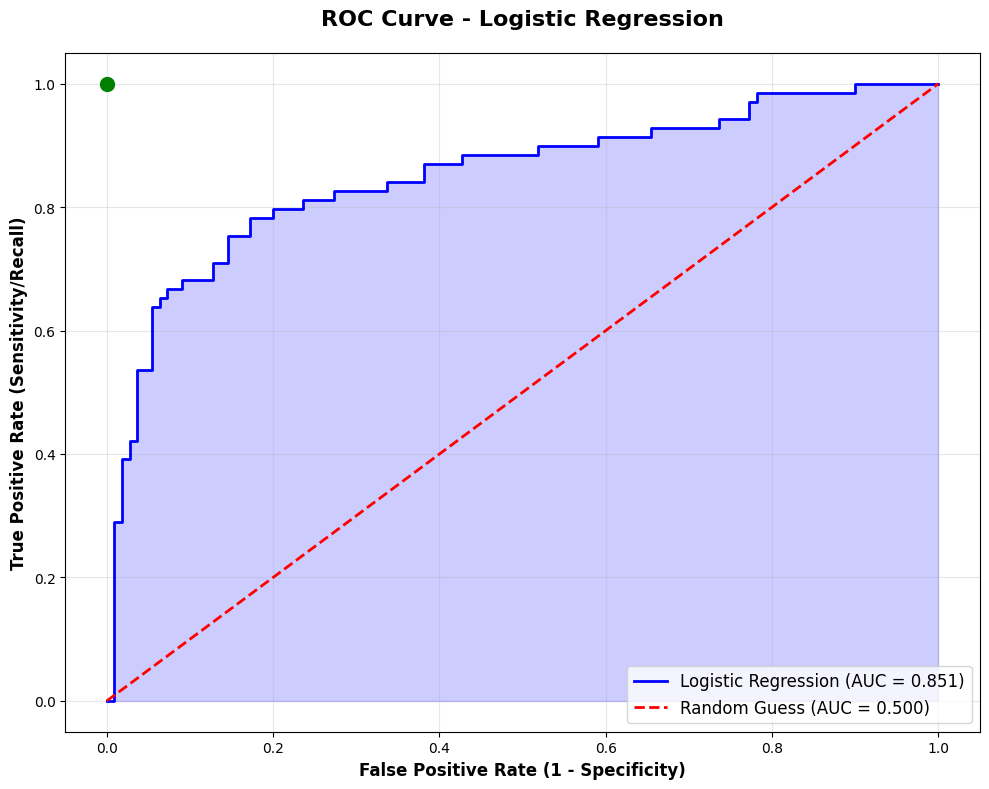


ROC CURVE ANALYSIS:
AUC Score: 0.8513


In [ ]:
# ROC Curve and AUC Score
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability predictions (not just 0/1)
y_pred_proba = model.predict_proba(X_val)[:, 1]  # Probability of survival

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)

# Calculate AUC score
auc_score = roc_auc_score(y_val, y_pred_proba)

# Plot ROC Curve
plt.figure(figsize=(10, 8))

# Plot the ROC curve
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'Logistic Regression (AUC = {auc_score:.3f})')

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=2, label='Random Guess (AUC = 0.500)')

# Formatting
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity/Recall)', fontsize=12, fontweight='bold')
plt.title('ROC Curve - Logistic Regression', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)

# Add perfect classifier point
plt.plot(0, 1, 'go', markersize=10, label='Perfect Classifier')

# Shade area under curve
plt.fill_between(fpr, tpr, alpha=0.2, color='blue')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ROC CURVE ANALYSIS:")
print("="*60)
print(f"AUC Score: {auc_score:.4f}")

 Training Random Forest model...
 Random Forest trained successfully!

RANDOM FOREST PERFORMANCE:
Validation Accuracy: 0.7933 (79.33%)

Comparison:
  Logistic Regression: 0.8045 (80.45%)
  Random Forest:       0.7933 (79.33%)
  Improvement:         -1.12%

DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Died       0.80      0.89      0.84       110
    Survived       0.79      0.64      0.70        69

    accuracy                           0.79       179
   macro avg       0.79      0.76      0.77       179
weighted avg       0.79      0.79      0.79       179


CONFUSION MATRIX:
[[98 12]
 [25 44]]

Interpretation:
  True Negatives (Correctly predicted Died): 98
  False Positives (Predicted Survived, but Actually Died): 12
  False Negatives (Predicted Died, but Actually Survived): 25
  True Positives (Correctly predicted Survived): 44


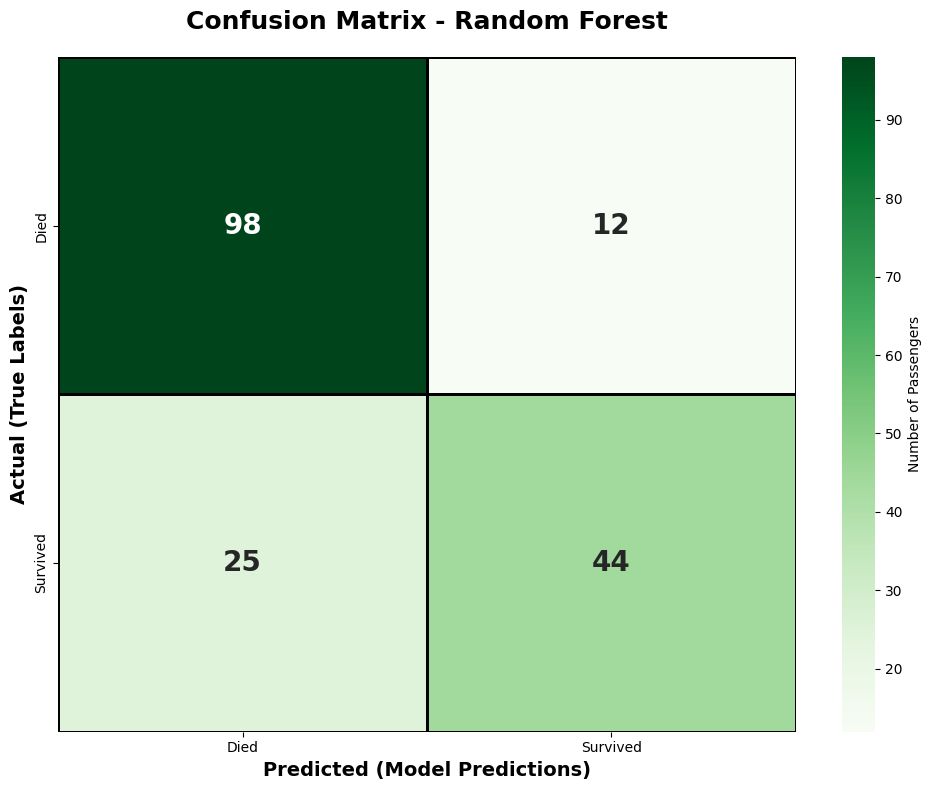


DETAILED BREAKDOWN:

 CORRECT PREDICTIONS: 142 out of 179 (79.3%)
   • True Negatives (Died - Died): 98
   • True Positives (Survived - Survived): 44

 INCORRECT PREDICTIONS: 37 out of 179 (20.7%)
   • False Positives (Died - Survived): 12
   • False Negatives (Survived - Died): 25

COMPARISON WITH LOGISTIC REGRESSION:
False Negatives (missed survivors):
  Logistic Regression: 22
  Random Forest:       25
  Improvement:         -3 fewer missed!


In [ ]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees in the forest
    max_depth=7,           # Maximum depth of each tree
    min_samples_split=10,  # Minimum samples to split a node
    min_samples_leaf=4,    # Minimum samples in a leaf
    random_state=42
)

# Train the model
print(" Training Random Forest model...")
rf_model.fit(X_train, y_train)
print(" Random Forest trained successfully!")

# Make predictions
y_pred_rf = rf_model.predict(X_val)

# Calculate accuracy
accuracy_rf = accuracy_score(y_val, y_pred_rf)

print("\n" + "="*60)
print("RANDOM FOREST PERFORMANCE:")
print("="*60)
print(f"Validation Accuracy: {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")

# Compare with Logistic Regression
print(f"\nComparison:")
print(f"  Logistic Regression: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Random Forest:       {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")
print(f"  Improvement:         {(accuracy_rf - accuracy)*100:.2f}%")

# Classification Report
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT:")
print("="*60)
print(classification_report(y_val, y_pred_rf, target_names=['Died', 'Survived']))

# Confusion Matrix
print("\n" + "="*60)
print("CONFUSION MATRIX:")
print("="*60)
cm_rf = confusion_matrix(y_val, y_pred_rf)
print(cm_rf)
print("\nInterpretation:")
print(f"  True Negatives (Correctly predicted Died): {cm_rf[0,0]}")
print(f"  False Positives (Predicted Survived, but Actually Died): {cm_rf[0,1]}")
print(f"  False Negatives (Predicted Died, but Actually Survived): {cm_rf[1,0]}")
print(f"  True Positives (Correctly predicted Survived): {cm_rf[1,1]}")

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'],
            cbar_kws={'label': 'Number of Passengers'},
            linewidths=2, linecolor='black',
            annot_kws={'size': 20, 'weight': 'bold'})

plt.title('Confusion Matrix - Random Forest', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Actual (True Labels)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted (Model Predictions)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Detailed Breakdown
print("\n" + "="*60)
print("DETAILED BREAKDOWN:")
print("="*60)

total = len(y_val)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf[0,0], cm_rf[0,1], cm_rf[1,0], cm_rf[1,1]

print(f"\n CORRECT PREDICTIONS: {tn_rf + tp_rf} out of {total} ({(tn_rf+tp_rf)/total*100:.1f}%)")
print(f"   • True Negatives (Died - Died): {tn_rf}")
print(f"   • True Positives (Survived - Survived): {tp_rf}")

print(f"\n INCORRECT PREDICTIONS: {fp_rf + fn_rf} out of {total} ({(fp_rf+fn_rf)/total*100:.1f}%)")
print(f"   • False Positives (Died - Survived): {fp_rf}")
print(f"   • False Negatives (Survived - Died): {fn_rf}")

# Compare errors
print("\n" + "="*60)
print("COMPARISON WITH LOGISTIC REGRESSION:")
print("="*60)
print(f"False Negatives (missed survivors):")
print(f"  Logistic Regression: 22")
print(f"  Random Forest:       {fn_rf}")
print(f"  Improvement:         {22 - fn_rf} fewer missed!")




ROC CURVE ANALYSIS:
Logistic Regression AUC: 0.8513
Random Forest AUC:       0.8316
Improvement:             -0.0196


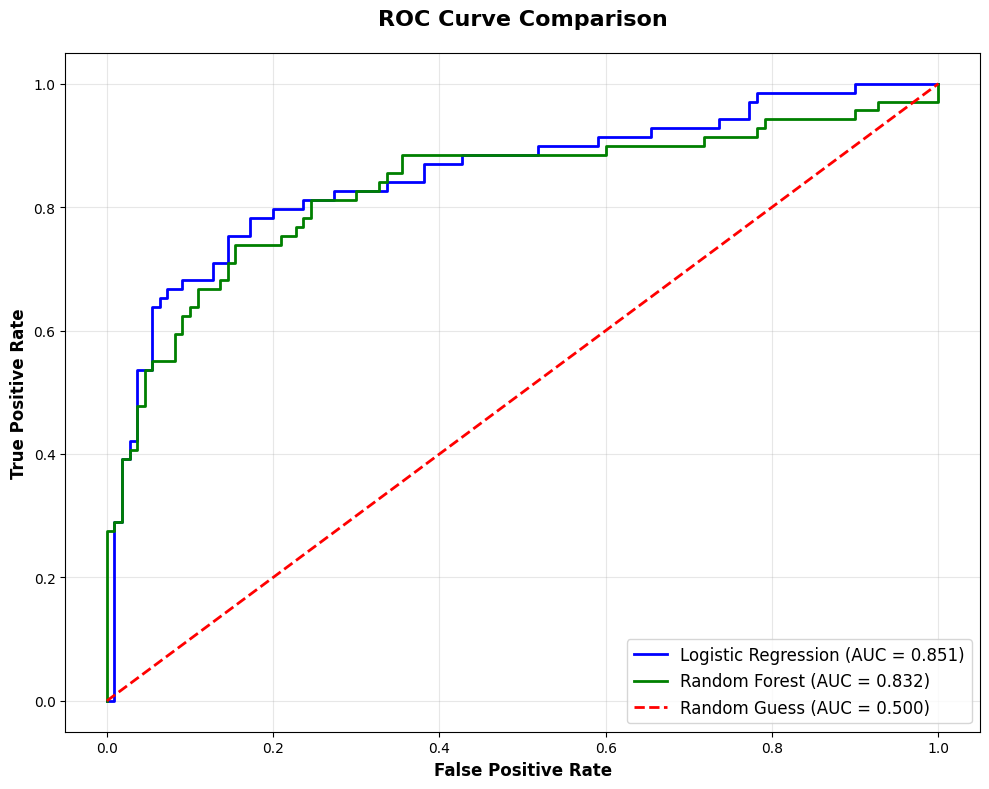

In [ ]:
# ROC Curve
y_pred_proba_rf = rf_model.predict_proba(X_val)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_pred_proba_rf)
auc_rf = roc_auc_score(y_val, y_pred_proba_rf)

print("\n" + "="*60)
print("ROC CURVE ANALYSIS:")
print("="*60)
print(f"Logistic Regression AUC: {auc_score:.4f}")
print(f"Random Forest AUC:       {auc_rf:.4f}")
print(f"Improvement:             {(auc_rf - auc_score):.4f}")

# Plot ROC comparison
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot(fpr_rf, tpr_rf, color='green', linewidth=2, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=2, label='Random Guess (AUC = 0.500)')

plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve Comparison', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Simpler Random Forest - Less constraints!
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model with SIMPLER settings
rf_model_v2 = RandomForestClassifier(
    n_estimators=200,      # More trees
    max_depth=None,        # No depth limit! Let trees grow
    min_samples_split=2,   # Default (minimum constraint)
    min_samples_leaf=1,    # Default (minimum constraint)
    max_features='sqrt',   # Use sqrt of features at each split
    random_state=42
)

print(" Training IMPROVED Random Forest...")
rf_model_v2.fit(X_train, y_train)
print(" Trained!")

# Predictions
y_pred_rf_v2 = rf_model_v2.predict(X_val)
accuracy_rf_v2 = accuracy_score(y_val, y_pred_rf_v2)

# Results
print("\n" + "="*60)
print("RESULTS COMPARISON:")
print("="*60)
print(f"Logistic Regression:        {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Random Forest (constrained): {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")
print(f"Random Forest (improved):    {accuracy_rf_v2:.4f} ({accuracy_rf_v2*100:.2f}%)")

# Classification Report
print("\n" + "="*60)
print("IMPROVED RANDOM FOREST REPORT:")
print("="*60)
print(classification_report(y_val, y_pred_rf_v2, target_names=['Died', 'Survived']))

# Confusion Matrix
cm_rf_v2 = confusion_matrix(y_val, y_pred_rf_v2)
print("\n" + "="*60)
print("CONFUSION MATRIX:")
print("="*60)
print(cm_rf_v2)
print(f"\nFalse Negatives (missed survivors): {cm_rf_v2[1,0]}")

 Training IMPROVED Random Forest...
 Trained!

RESULTS COMPARISON:
Logistic Regression:        0.8045 (80.45%)
Random Forest (constrained): 0.7933 (79.33%)
Random Forest (improved):    0.8156 (81.56%)

IMPROVED RANDOM FOREST REPORT:
              precision    recall  f1-score   support

        Died       0.83      0.87      0.85       110
    Survived       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179


CONFUSION MATRIX:
[[96 14]
 [19 50]]

False Negatives (missed survivors): 19


In [ ]:
# Use the BEST model (Random Forest improved) to predict on test data
print(" Making predictions on test data...")

# Predict survival for test passengers
test_predictions = rf_model_v2.predict(X_test_scaled)

print(f" Predicted survival for {len(test_predictions)} passengers!")

# Show distribution of predictions
survived_count = test_predictions.sum()
died_count = len(test_predictions) - survived_count

print("\n" + "="*60)
print("PREDICTION SUMMARY:")
print("="*60)
print(f"Total passengers in test set: {len(test_predictions)}")
print(f"Predicted to DIE: {died_count} ({died_count/len(test_predictions)*100:.1f}%)")
print(f"Predicted to SURVIVE: {survived_count} ({survived_count/len(test_predictions)*100:.1f}%)")

# Create submission file
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': test_predictions
})

# Save to CSV
submission.to_csv('titanic_submission.csv', index=False)

print("\n" + "="*60)
print("SUBMISSION FILE CREATED!")
print("="*60)
print(f"File name: titanic_submission.csv")
print(f"Total predictions: {len(submission)}")

# Show first 10 predictions
print("\n" + "="*60)
print("FIRST 10 PREDICTIONS:")
print("="*60)
print(submission.head(10))



 Making predictions on test data...
 Predicted survival for 418 passengers!

PREDICTION SUMMARY:
Total passengers in test set: 418
Predicted to DIE: 272 (65.1%)
Predicted to SURVIVE: 146 (34.9%)

SUBMISSION FILE CREATED!
File name: titanic_submission.csv
Total predictions: 418

FIRST 10 PREDICTIONS:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         1
4          896         0
5          897         0
6          898         0
7          899         0
8          900         1
9          901         0
